In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
deliveries = pd.read_csv('../data/deliveries.csv')
matches = pd.read_csv('../data/matches.csv')

df = deliveries.merge(matches[['id', 'season']], left_on='match_id', right_on='id', how='left')

In [3]:
# Identifing if a delivery resulted in a boundary (4 or 6)
df['is_boundary'] = df['batsman_runs'].isin([4, 6]).astype(int)

In [4]:
#  All-Time Boundary Leaders
all_time_stats = df.groupby('batting_team')['is_boundary'].sum().reset_index()
all_time_stats.rename(columns={'is_boundary': 'Total_All_Time_Boundaries'}, inplace=True)
all_time_stats = all_time_stats.sort_values(by='Total_All_Time_Boundaries', ascending=False).reset_index(drop=True)

In [5]:
print(all_time_stats.head().to_string())

                  batting_team  Total_All_Time_Boundaries
0               Mumbai Indians                       5322
1        Kolkata Knight Riders                       4956
2          Chennai Super Kings                       4705
3  Royal Challengers Bangalore                       4637
4             Rajasthan Royals                       4328


In [6]:
# Latest Season (2024) Leaders
latest_season = df['season'].max()

latest_season_df = df[df['season'] == latest_season]

latest_season_stats = latest_season_df.groupby('batting_team')['is_boundary'].sum().reset_index()
latest_season_stats.rename(columns={'is_boundary': f'Boundaries_in_{latest_season}'}, inplace=True)
latest_season_stats = latest_season_stats.sort_values(by=f'Boundaries_in_{latest_season}', ascending=False).reset_index(drop=True)

In [7]:
print(f"Top 5 Teams in the most recent season ({latest_season}):")
print(latest_season_stats.head().to_string())

Top 5 Teams in the most recent season (2024):
                  batting_team  Boundaries_in_2024
0          Sunrisers Hyderabad                 395
1  Royal Challengers Bengaluru                 394
2        Kolkata Knight Riders                 379
3               Delhi Capitals                 364
4             Rajasthan Royals                 348


C:\Users\aman3133\AppData\Local\Temp\ipykernel_32944\2000677043.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=latest_season_stats.head(8), x='Boundaries_in_2024', y='batting_team', palette='viridis')


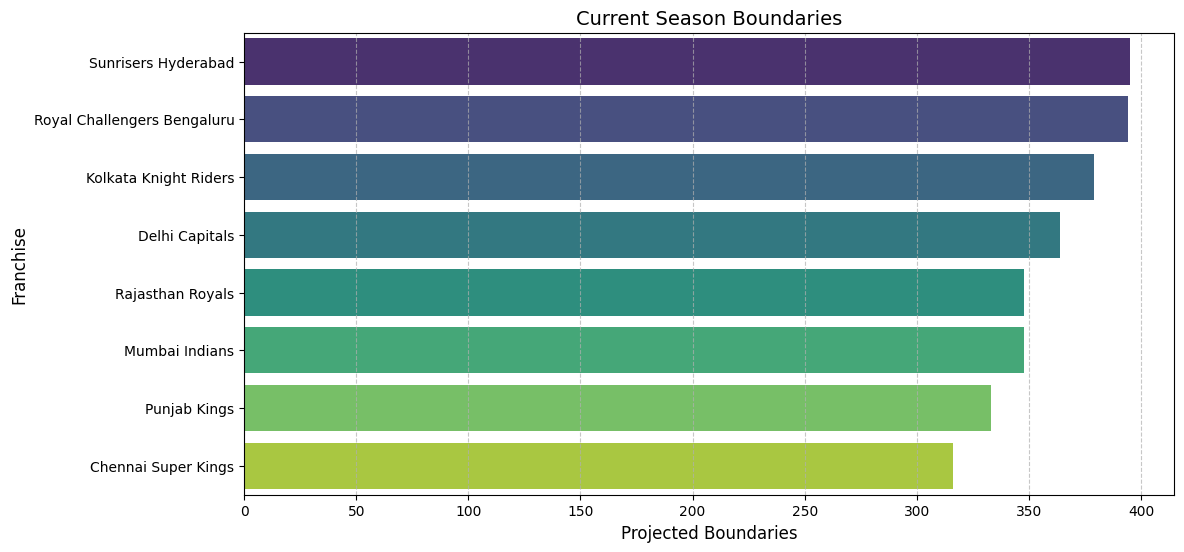

In [8]:
plt.figure(figsize=(12, 6))
sns.barplot(data=latest_season_stats.head(8), x='Boundaries_in_2024', y='batting_team', palette='viridis')
plt.title(f'Current Season Boundaries', fontsize=14)
plt.xlabel('Projected Boundaries', fontsize=12)
plt.ylabel('Franchise', fontsize=12)
plt.grid(axis = 'x', linestyle='--', alpha=0.7)
plt.show()

In [9]:
# Getting the list of the last 3 unique seasons
recent_3_seasons = sorted(df['season'].unique())[-3:]

last_3_years_df = df[df['season'].isin(recent_3_seasons)]

In [10]:
# Group by season and team to get boundaries per season, then average them
seasonal_boundaries = last_3_years_df.groupby(['season', 'batting_team'])['is_boundary'].sum().reset_index()
predicted_boundaries = seasonal_boundaries.groupby('batting_team')['is_boundary'].mean().reset_index()
predicted_boundaries.rename(columns={'is_boundary': 'Projected_Boundaries_Next_Season'}, inplace=True)

# Round the projections and sort
predicted_boundaries['Projected_Boundaries_Next_Season'] = predicted_boundaries['Projected_Boundaries_Next_Season'].round(0).astype(int)
predicted_boundaries = predicted_boundaries.sort_values(by='Projected_Boundaries_Next_Season', ascending=False).reset_index(drop=True)

In [11]:
print(f"Simple Prediction For Next Season (Based on {recent_3_seasons[-3]}-{recent_3_seasons[-1]} Average):")
print(predicted_boundaries.head(10).to_string())

Simple Prediction For Next Season (Based on 2022-2024 Average):
                  batting_team  Projected_Boundaries_Next_Season
0  Royal Challengers Bengaluru                               394
1             Rajasthan Royals                               354
2               Mumbai Indians                               342
3        Kolkata Knight Riders                               332
4                 Punjab Kings                               329
5               Gujarat Titans                               321
6          Sunrisers Hyderabad                               321
7               Delhi Capitals                               317
8  Royal Challengers Bangalore                               316
9          Chennai Super Kings                               311


C:\Users\aman3133\AppData\Local\Temp\ipykernel_32944\1485713666.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=predicted_boundaries.head(8), x='Projected_Boundaries_Next_Season', y='batting_team', palette='viridis')


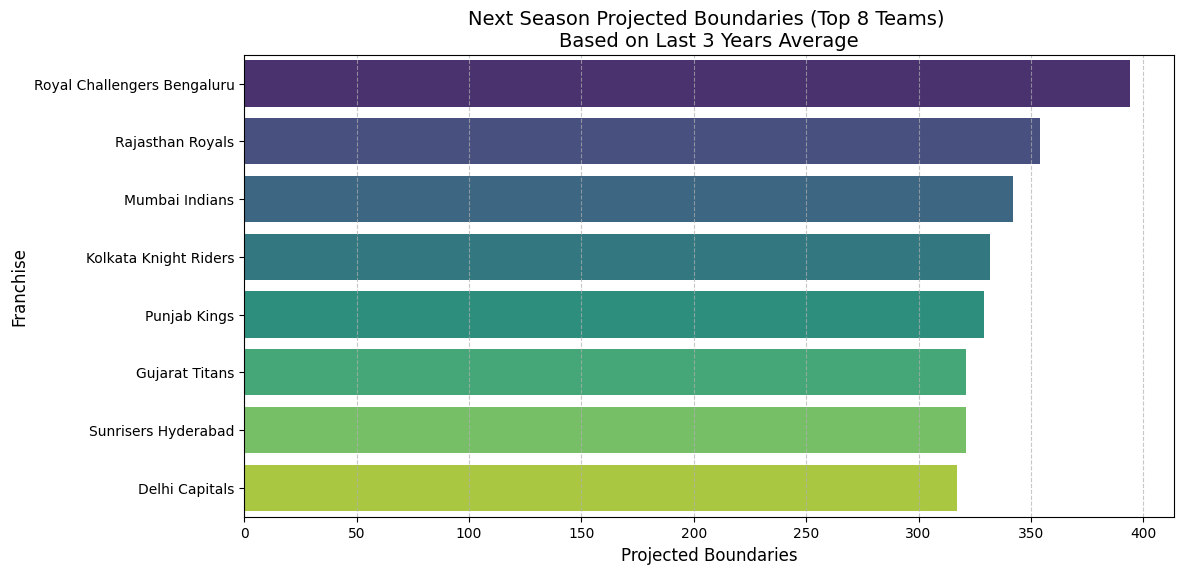

In [12]:
# VISUALIZATION 
plt.figure(figsize=(12, 6))
sns.barplot(data=predicted_boundaries.head(8), x='Projected_Boundaries_Next_Season', y='batting_team', palette='viridis')
plt.title(f'Next Season Projected Boundaries (Top 8 Teams) \nBased on Last 3 Years Average', fontsize=14)
plt.xlabel('Projected Boundaries', fontsize=12)
plt.ylabel('Franchise', fontsize=12)
plt.grid(axis = 'x', linestyle='--', alpha=0.7)
plt.show()
